In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

In [2]:
# Load your exported CSV
df = pd.read_csv(r"/Users/suthardr/Desktop/Revision/IHC_Counts.csv")
df

,Stain,Mouse,Specificity
0,NeuN,F8,0.647
1,NeuN,F10,0.000
2,NeuN,F6,0.289
3,NeuN,M6,0.000
4,GFAP,F6,99.598
5,GFAP,F3,100.000
6,GFAP,M5,100.000
7,GFAP,F5,100.000
8,GFAP,M7,99.740


In [3]:
import pandas as pd
from scipy import stats

# Split groups
group_a_values = df[df['Stain'] == 'GFAP']['Specificity']
group_b_values = df[df['Stain'] == 'NeuN']['Specificity']

# Run Welch’s t-test (safer)
t_statistic, p_value = stats.ttest_ind(group_a_values, group_b_values, equal_var=False)

print("T-statistic:", t_statistic)
print("P-value:", p_value)


T-statistic: 568.9177108686482
P-value: 1.155586401212097e-12


In [28]:
def plot_avg_specificity(df, title="", save_path=None):
    sns.set(style="ticks", font="Arial")
    plt.rcParams.update({'font.size': 8})

    fig, ax = plt.subplots(figsize=(3, 4), dpi=600)

    # Barplot — assign color list manually using palette override
    sns.barplot(
        x='Stain', y='Specificity', data=df,
         ci=68, capsize=.2, errwidth=1,
        alpha=0.8, ax=ax
    )

    # Stripplot — black dots on top of each bar
    sns.stripplot(
        x='Stain', y='Specificity', data=df,
        jitter=True, linewidth=0.3, edgecolor='black',
        size=4, ax=ax
    )

    ax.legend_.remove() if ax.legend_ else None
    ax.set_ylabel('Specificity (% Stain/GCaMP+)', fontsize=10)
    ax.set_xlabel('', fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_ylim(-1, 105)
    ax.set_title(title, fontsize=10, pad=10)
    sns.despine()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight', format='svg')
    plt.show()
    return fig, ax


/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_19959/285614465.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(
/Users/suthardr/opt/anaconda3/envs/dCA1_Paper/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/suthardr/opt/anaconda3/envs/dCA1_Paper/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


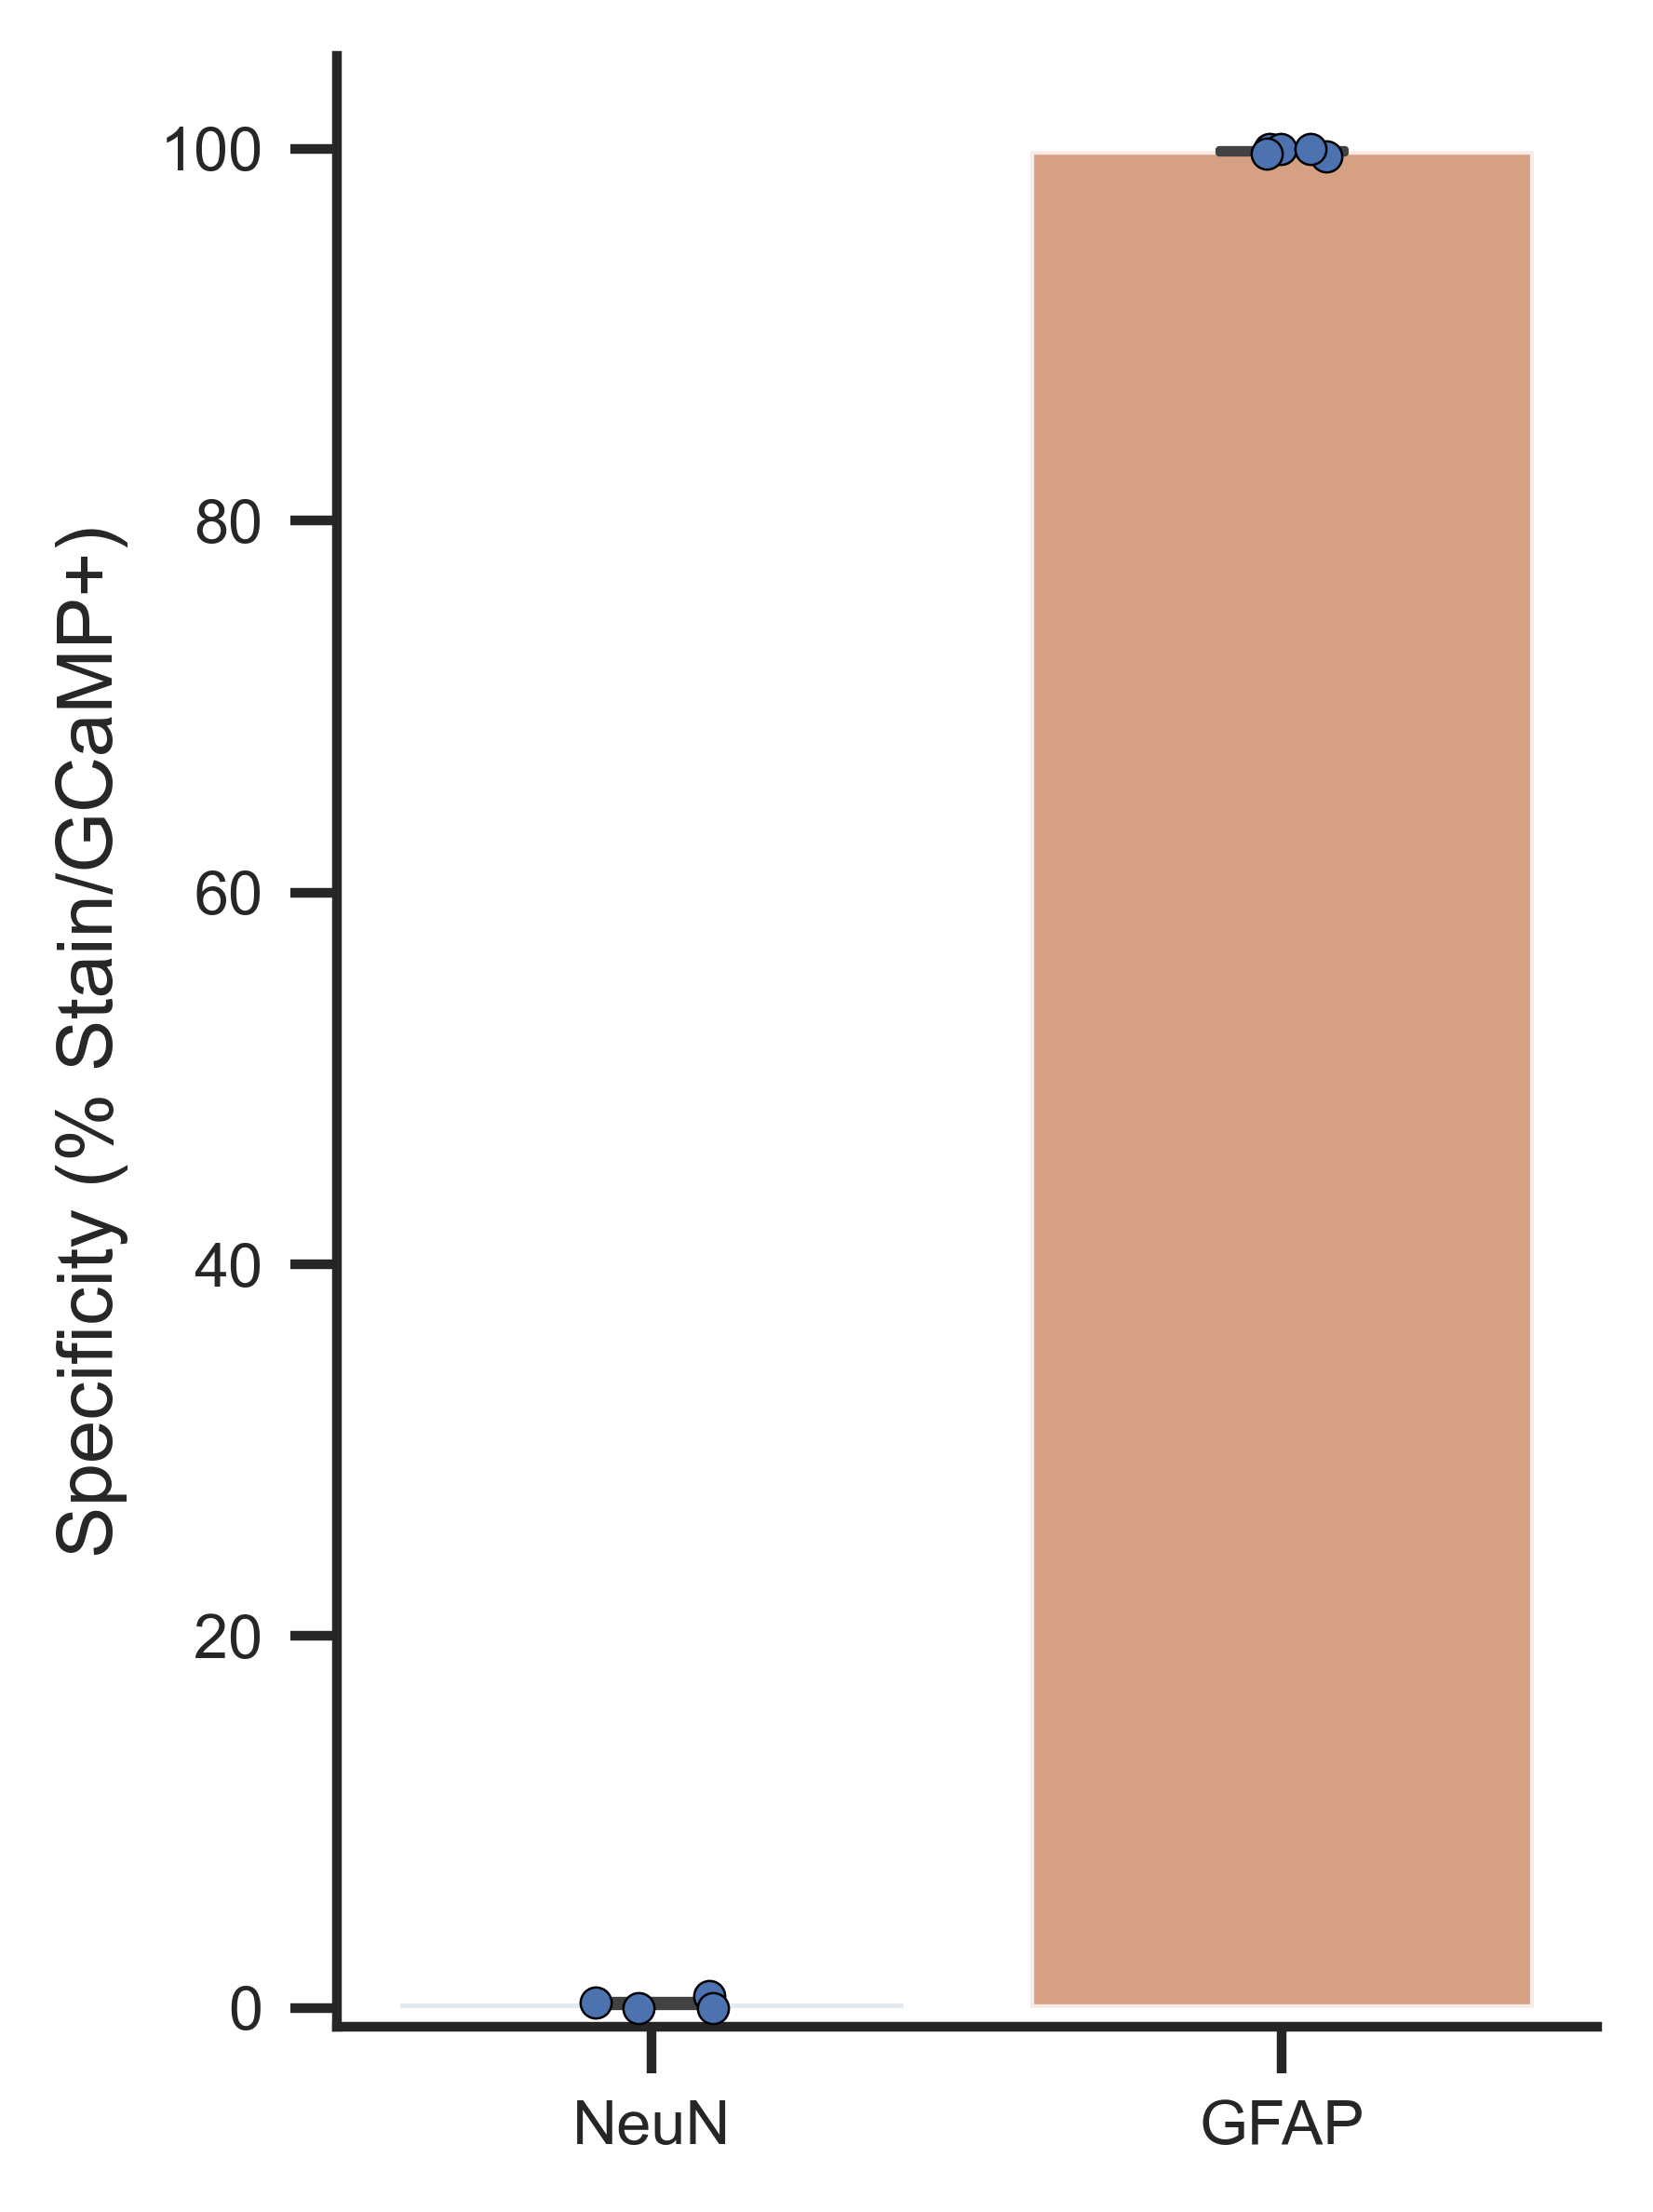

(<Figure size 1800x2400 with 1 Axes>,
 <Axes: ylabel='Specificity (% Stain/GCaMP+)'>)

In [29]:
plot_avg_specificity(df,save_path="/Users/suthardr/Desktop/Revision/IHC_Specificity_Barplot.svg" )